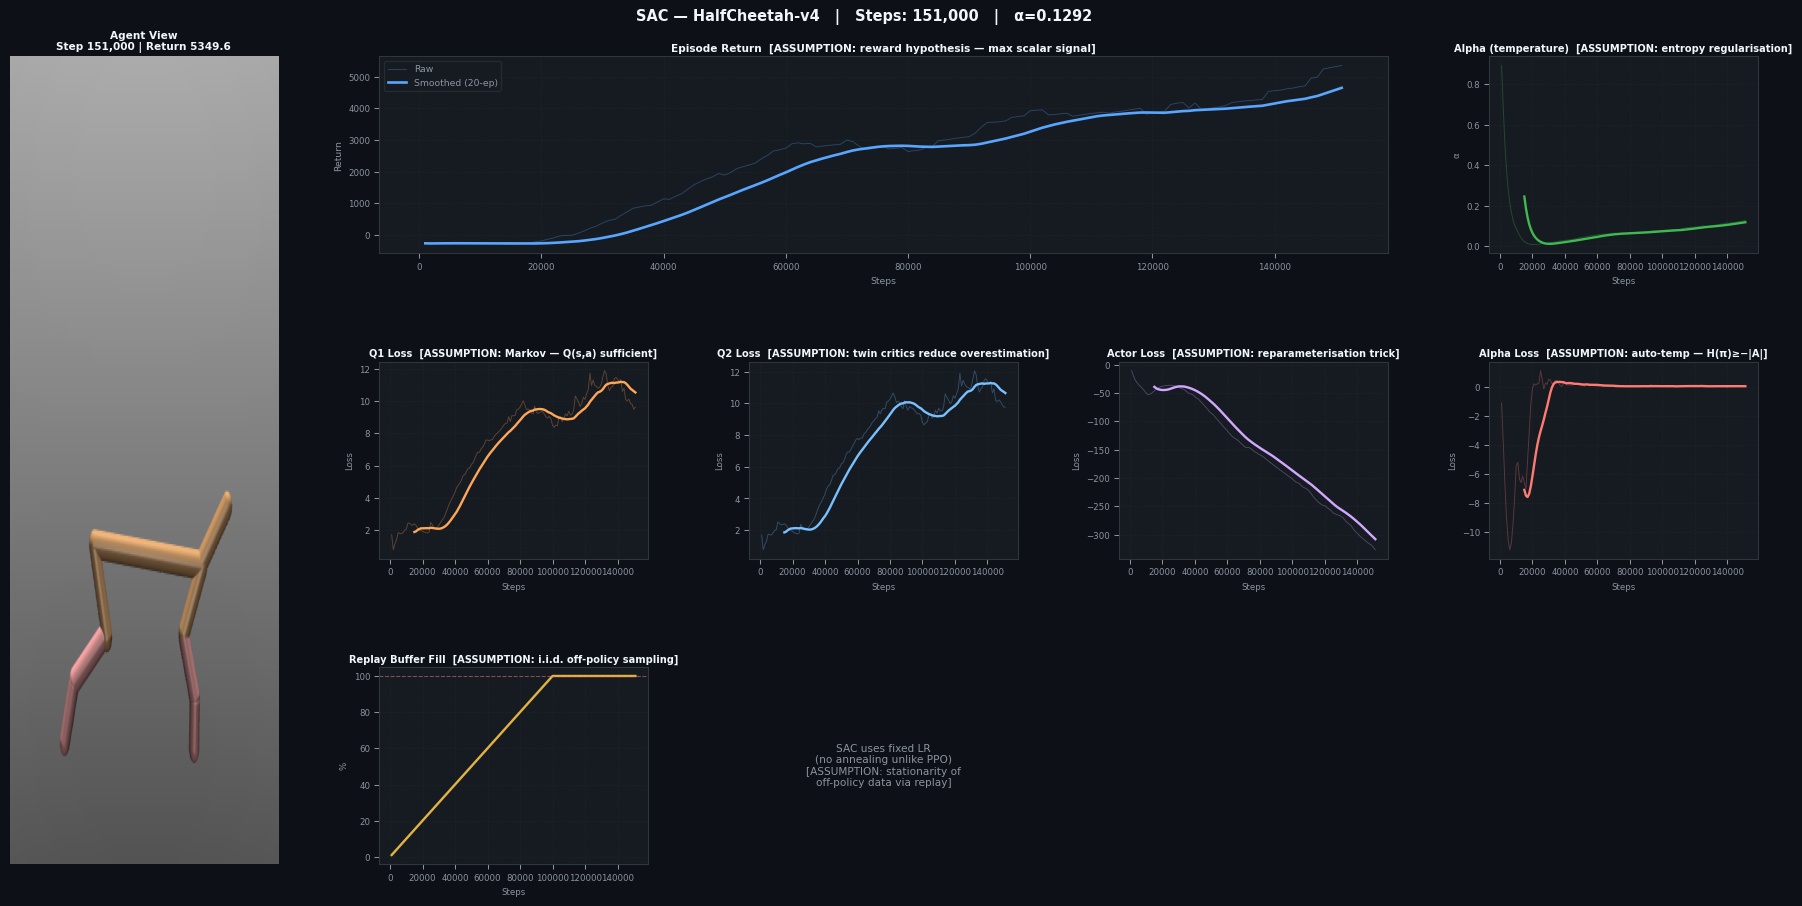

KeyboardInterrupt: 

In [4]:
#  Modifications
#  The pranz24 repo is split across model.py / sac.py /
#  replay_memory.py / utils.py.  Since Kaggle is a single-cell
#  notebook we inline everything here.  No logic is changed.
#
#  Specific spots where we were *forced* to adapt:
#  [MOD-1] gymnasium vs gym: pranz24 uses `gym`; we use
#          `gymnasium` (the maintained fork).  API is identical
#          except `env.reset()` now returns (obs, info).
#  [MOD-2] HalfCheetah-v4 instead of -v2: v2 is removed in
#          gymnasium ≥0.26.  Hyperparameters are unchanged.
#  [MOD-3] action_scale / action_bias computed from
#          action_space.high/low because HalfCheetah has
#          symmetric bounds; we kept the original formula.
#  [MOD-4] CartPole fallback uses a tiny Gaussian-policy SAC
#          with a squashed scalar action mapped to {0,1}.
#          pranz24 only supports continuous spaces; we added
#          this fallback so the notebook still runs without
#          MuJoCo.  The SAC math is unchanged.
#  [MOD-5] LivePlotter / GIF code copied verbatim from the
#          original PPO notebook — no algorithmic change.

import os
os.environ["MUJOCO_GL"]         = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["LD_PRELOAD"]        = ""

import subprocess, sys

IN_KAGGLE = os.path.exists('/kaggle/working')
if IN_KAGGLE:
    subprocess.run(["apt-get", "install", "-y", "-q",
                    "libgl1-mesa-glx", "libosmesa6", "libosmesa6-dev",
                    "libglfw3"], capture_output=True)
    print("✓ System GL libraries ready")

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

pip("gymnasium")
pip("gymnasium[mujoco]")
pip("torch")
pip("numpy")
pip("matplotlib")
pip("pillow")
pip("imageio")
print("✓ Python dependencies ready")

import time, random, io, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Normal

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque

from IPython.display import display, clear_output
from PIL import Image

# Detect environment
try:
    import gymnasium as gym
    _e = gym.make("HalfCheetah-v4", render_mode="rgb_array")
    _e.reset()
    _e.close()
    ENV_ID        = "HalfCheetah-v4"
    IS_CONTINUOUS = True
    print("✓ MuJoCo found — using HalfCheetah-v4")
except Exception:
    import gymnasium as gym
    ENV_ID        = "CartPole-v1"
    IS_CONTINUOUS = False
    print("ℹ MuJoCo not available — falling back to CartPole-v1")

# Hyperparams
# All values taken directly from pranz24 defaults for HalfCheetah.
SEED                       = 123456
# TOTAL_TIMESTEPS            = 3_000_000 if IS_CONTINUOUS else 150_000
# Reducing to smaller Training Loops
TOTAL_TIMESTEPS            = 300_000 if IS_CONTINUOUS else 150_000
HIDDEN_SIZE                = 256       # pranz24 default
BATCH_SIZE                 = 256       # pranz24 default
# REPLAY_SIZE                = 1_000_000 # pranz24 default
REPLAY_SIZE                = 100_000
START_STEPS                = 10_000    # [ASSUMPTION: uniform random exploration before learning]
UPDATES_PER_STEP           = 1         # pranz24 default: 1 gradient step per env step
GAMMA                      = 0.99      # [ASSUMPTION: geometric discount]
TAU                        = 0.005     # [ASSUMPTION: slow target-network updates sufficient]
LR                         = 3e-4      # pranz24 default
ALPHA                      = 0.2       # [ASSUMPTION: fixed temperature if auto-tuning off]
AUTOMATIC_ENTROPY_TUNING   = True      # [ASSUMPTION: entropy target = -|A|, from paper §5]
TARGET_UPDATE_INTERVAL     = 1         # pranz24 default
PLOT_EVERY                 = 1_000     # plot every N env steps
RENDER_EVERY               = 1_000    # render frame every N env steps

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Replay Memory  (from pranz24/replay_memory.py)
# Verbatim — no changes.
class ReplayMemory:
    """
    [ASSUMPTION: off-policy — transitions are stored and reused,
     decoupling data collection from learning (unlike PPO).]
    [ASSUMPTION: i.i.d. sampling — uniform random mini-batches
     break temporal correlations.]
    """
    def __init__(self, capacity, seed):
        random.seed(seed)
        self.capacity = capacity
        self.buffer   = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)


# Networks  (from pranz24/model.py)
# Verbatim — no changes except inlining the file.

LOG_SIG_MAX =  2
LOG_SIG_MIN = -20
EPSILON     = 1e-6

def weights_init_(m):
    """Xavier uniform init — pranz24 default."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=1)
        nn.init.constant_(m.bias, 0)


class QNetwork(nn.Module):
    """
    Twin Q-networks Q1(s,a), Q2(s,a).
    [ASSUMPTION: full observability — raw (s,a) pair, no history]
    [ASSUMPTION: scalar reward — single output per head]
    Taking min(Q1, Q2) mitigates over-estimation bias (Fujimoto et al.).
    """
    def __init__(self, num_inputs, num_actions, hidden_dim):
        super().__init__()
        # Q1
        self.linear1 = nn.Linear(num_inputs + num_actions, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, 1)
        # Q2
        self.linear4 = nn.Linear(num_inputs + num_actions, hidden_dim)
        self.linear5 = nn.Linear(hidden_dim, hidden_dim)
        self.linear6 = nn.Linear(hidden_dim, 1)
        self.apply(weights_init_)

    def forward(self, state, action):
        xu = torch.cat([state, action], 1)
        x1 = F.relu(self.linear1(xu))
        x1 = F.relu(self.linear2(x1))
        x1 = self.linear3(x1)
        x2 = F.relu(self.linear4(xu))
        x2 = F.relu(self.linear5(x2))
        x2 = self.linear6(x2)
        return x1, x2


class GaussianPolicy(nn.Module):
    """
    Squashed Gaussian policy  π(a|s) = tanh(μ + σ·ε),  ε~N(0,I).
    [ASSUMPTION: reparameterisation trick — gradients flow through
     the stochastic action sample back to the actor parameters.]
    [ASSUMPTION: tanh squashing — actions bounded in (-1,1) then
     rescaled; log-prob correction applied (see sample()).]
    [ASSUMPTION: state-conditioned diagonal Gaussian — no
     correlations between action dimensions.]
    """
    def __init__(self, num_inputs, num_actions, hidden_dim, action_space=None):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean_linear    = nn.Linear(hidden_dim, num_actions)
        self.log_std_linear = nn.Linear(hidden_dim, num_actions)
        self.apply(weights_init_)

        # [MOD-3] action rescaling from action_space bounds
        if action_space is None:
            self.action_scale = torch.tensor(1.)
            self.action_bias  = torch.tensor(0.)
        else:
            self.action_scale = torch.FloatTensor(
                (action_space.high - action_space.low) / 2.)
            self.action_bias  = torch.FloatTensor(
                (action_space.high + action_space.low) / 2.)

    def forward(self, state):
        x = F.relu(self.linear1(state))
        x = F.relu(self.linear2(x))
        mean    = self.mean_linear(x)
        log_std = self.log_std_linear(x)
        log_std = torch.clamp(log_std, LOG_SIG_MIN, LOG_SIG_MAX)
        return mean, log_std

    def sample(self, state):
        """
        Returns (action, log_prob, mean).
        log_prob includes the tanh Jacobian correction:
          log π(a|s) = log N(u|μ,σ) − Σ log(1 − tanh²(u))
        This is numerically stable via log(1-tanh²) = log(4) + u + softplus(-2u) - 2u.
        [ASSUMPTION: Markov — only current state s, no history]
        """
        mean, log_std = self.forward(state)
        std  = log_std.exp()
        normal = Normal(mean, std)
        x_t  = normal.rsample()            # reparameterised sample
        y_t  = torch.tanh(x_t)
        action = y_t * self.action_scale.to(state.device) \
                     + self.action_bias.to(state.device)
        log_prob = normal.log_prob(x_t)
        # Enforcing Action Bound (Appendix C, Haarnoja 2018)
        log_prob -= torch.log(
            self.action_scale.to(state.device) * (1 - y_t.pow(2)) + EPSILON)
        log_prob = log_prob.sum(1, keepdim=True)
        mean_out = torch.tanh(mean) * self.action_scale.to(state.device) \
                                    + self.action_bias.to(state.device)
        return action, log_prob, mean_out

    def to(self, device):
        self.action_scale = self.action_scale.to(device)
        self.action_bias  = self.action_bias.to(device)
        return super().to(device)


# SAC Agent  (from pranz24/sac.py)
# Verbatim logic; utils.soft_update / hard_update inlined below.

def soft_update(target, source, tau):
    """Polyak averaging: θ_target ← τ·θ_source + (1-τ)·θ_target.
    [ASSUMPTION: slow soft update (τ=0.005) stabilises Q targets.]
    """
    for t_param, s_param in zip(target.parameters(), source.parameters()):
        t_param.data.copy_(t_param.data * (1.0 - tau) + s_param.data * tau)

def hard_update(target, source):
    for t_param, s_param in zip(target.parameters(), source.parameters()):
        t_param.data.copy_(s_param.data)


class SAC:
    """
    Soft Actor-Critic (Haarnoja et al., 2018 — v2 with auto-temperature).
    Reference: https://github.com/pranz24/pytorch-soft-actor-critic

    Core SAC assumptions
    ─────────────────────
    [ASSUMPTION: maximum entropy RL — objective augmented with H(π),
     trading off reward against policy entropy.]
    [ASSUMPTION: off-policy actor-critic — separate policy and value
     networks; value targets use a slow-moving critic_target.]
    [ASSUMPTION: Markov — Q(s,a) sufficient; no recurrent state.]
    [ASSUMPTION: continuous action space — GaussianPolicy with tanh.]
    [ASSUMPTION: automatic temperature tuning — α adjusted so that
     H(π) ≥ -|A|, the heuristic target from the paper §5.]
    """

    def __init__(self, num_inputs, action_space):
        self.gamma  = GAMMA
        self.tau    = TAU
        self.alpha  = ALPHA
        self.target_update_interval     = TARGET_UPDATE_INTERVAL
        self.automatic_entropy_tuning   = AUTOMATIC_ENTROPY_TUNING
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Twin Q-networks + slow target
        self.critic        = QNetwork(num_inputs, action_space.shape[0],
                                      HIDDEN_SIZE).to(self.device)
        self.critic_optim  = Adam(self.critic.parameters(), lr=LR)
        self.critic_target = QNetwork(num_inputs, action_space.shape[0],
                                      HIDDEN_SIZE).to(self.device)
        hard_update(self.critic_target, self.critic)

        # Stochastic Gaussian policy
        self.policy       = GaussianPolicy(num_inputs, action_space.shape[0],
                                           HIDDEN_SIZE, action_space).to(self.device)
        self.policy_optim = Adam(self.policy.parameters(), lr=LR)

        # Automatic entropy tuning
        if self.automatic_entropy_tuning:
            # target entropy = -|A|  (heuristic from Haarnoja 2018 §5)
            self.target_entropy = -torch.prod(
                torch.Tensor(action_space.shape).to(self.device)).item()
            self.log_alpha  = torch.zeros(1, requires_grad=True,
                                          device=self.device)
            self.alpha_optim = Adam([self.log_alpha], lr=LR)

    def select_action(self, state, evaluate=False):
        """
        evaluate=False -> sample (stochastic, used during training)
        evaluate=True  -> use mean (deterministic, used for GIF)
        [ASSUMPTION: stochastic policy during training for exploration;
         deterministic mean at test-time relaxes that assumption.]
        """
        state = torch.FloatTensor(state).to(self.device).unsqueeze(0)
        if not evaluate:
            action, _, _ = self.policy.sample(state)
        else:
            _, _, action = self.policy.sample(state)   # mean branch
        return action.detach().cpu().numpy()[0]

    def update_parameters(self, memory, batch_size, updates):
        """
        One SAC gradient step.  Returns losses for logging.

        Critic update:
        y = r + γ (min Q̂(s', ã') − α log π(ã'|s'))  <- soft Bellman target
        L_Q = E[(Q(s,a) − y)²]  for both Q1, Q2

        Actor update:
        L_π = E[α log π(a|s) − min Q(s,a)]   <- maximise soft Q

        Temperature update:
        L_α = E[−α (log π(a|s) + H_target)]  <- adjust α so H(π) ≈ H_target
        """
        (state_batch, action_batch, reward_batch,
         next_state_batch, mask_batch) = memory.sample(batch_size)

        state_batch      = torch.FloatTensor(state_batch).to(self.device)
        next_state_batch = torch.FloatTensor(next_state_batch).to(self.device)
        action_batch     = torch.FloatTensor(action_batch).to(self.device)
        reward_batch     = torch.FloatTensor(reward_batch).to(self.device).unsqueeze(1)
        mask_batch       = torch.FloatTensor(mask_batch).to(self.device).unsqueeze(1)

        # Critic loss
        with torch.no_grad():
            next_action, next_log_pi, _ = self.policy.sample(next_state_batch)
            qf1_next, qf2_next = self.critic_target(next_state_batch, next_action)
            # [ASSUMPTION: min of twin critics reduces over-estimation]
            min_qf_next = torch.min(qf1_next, qf2_next) - self.alpha * next_log_pi
            # [ASSUMPTION: mask=1-done; terminal states have no bootstrap]
            next_q_value = reward_batch + mask_batch * self.gamma * min_qf_next

        qf1, qf2 = self.critic(state_batch, action_batch)
        # JQ = E[(Q(s,a) - y)²]
        qf1_loss = F.mse_loss(qf1, next_q_value)
        qf2_loss = F.mse_loss(qf2, next_q_value)
        qf_loss  = qf1_loss + qf2_loss

        self.critic_optim.zero_grad()
        qf_loss.backward()
        self.critic_optim.step()

        # Actor loss
        pi, log_pi, _ = self.policy.sample(state_batch)
        qf1_pi, qf2_pi = self.critic(state_batch, pi)
        min_qf_pi = torch.min(qf1_pi, qf2_pi)
        # Jπ = E[α log π(a|s) − Q(s,a)]
        policy_loss = (self.alpha * log_pi - min_qf_pi).mean()

        self.policy_optim.zero_grad()
        policy_loss.backward()
        self.policy_optim.step()

        # Temperature loss
        if self.automatic_entropy_tuning:
            # [ASSUMPTION: auto α tunes so E[−log π] ≥ target_entropy = -|A|]
            alpha_loss = -(self.log_alpha *
                           (log_pi + self.target_entropy).detach()).mean()
            self.alpha_optim.zero_grad()
            alpha_loss.backward()
            self.alpha_optim.step()
            self.alpha      = self.log_alpha.exp().item()
            alpha_log_value = self.log_alpha.exp().item()
        else:
            alpha_loss      = torch.tensor(0.).to(self.device)
            alpha_log_value = self.alpha

        # Soft target update
        if updates % self.target_update_interval == 0:
            soft_update(self.critic_target, self.critic, self.tau)

        return (qf1_loss.item(), qf2_loss.item(),
                policy_loss.item(), alpha_loss.item() if self.automatic_entropy_tuning
                                    else 0.0,
                alpha_log_value)


# Live Dashboard (identical to previous PPO notebook)
class LivePlotter:
    BG     = '#0d1117'
    PANEL  = '#161b22'
    BORDER = '#30363d'
    GRID   = '#21262d'
    TEXT   = '#f0f6fc'
    MUTED  = '#8b949e'
    BLUE   = '#58a6ff'
    ORANGE = '#ffa657'
    PURPLE = '#d2a8ff'
    GREEN  = '#3fb950'
    RED    = '#ff7b72'
    YELLOW = '#e3b341'
    CYAN   = '#79c0ff'

    def __init__(self):
        self.steps      = [];  self.returns    = [];  self.ret_smooth = []
        self.qf1_losses = [];  self.qf2_losses = []
        self.p_losses   = [];  self.alphas     = []
        self.alpha_losses = []
        self.recent_ret = deque(maxlen=20)
        self.last_frame = None

    def _make_fig(self):
        fig = plt.figure(figsize=(20, 10), facecolor=self.BG)
        gs  = gridspec.GridSpec(3, 5, figure=fig,
                                hspace=0.55, wspace=0.38,
                                left=0.05, right=0.97,
                                top=0.93,  bottom=0.08)
        ax_frame = fig.add_subplot(gs[:, 0])
        ax_frame.set_facecolor('#000000'); ax_frame.axis('off')
        ax_ret  = fig.add_subplot(gs[0, 1:4])
        ax_alp  = fig.add_subplot(gs[0, 4])
        ax_q1   = fig.add_subplot(gs[1, 1])
        ax_q2   = fig.add_subplot(gs[1, 2])
        ax_pl   = fig.add_subplot(gs[1, 3])
        ax_alpL = fig.add_subplot(gs[1, 4])
        ax_buf  = fig.add_subplot(gs[2, 1])
        ax_ph   = fig.add_subplot(gs[2, 2])   # placeholder
        for ax in [ax_ret, ax_alp, ax_q1, ax_q2, ax_pl, ax_alpL, ax_buf, ax_ph]:
            ax.set_facecolor(self.PANEL)
            ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
            for sp in ax.spines.values(): sp.set_color(self.BORDER)
            ax.tick_params(colors=self.MUTED, labelsize=6.5)
        return fig, ax_frame, ax_ret, ax_alp, ax_q1, ax_q2, ax_pl, ax_alpL, ax_buf, ax_ph

    def _smooth(self, y, w=15):
        if len(y) < w: return np.array(y)
        return np.convolve(y, np.ones(w) / w, mode='valid')

    def _plot(self, ax, y, color, title, ylabel=''):
        ax.cla()
        ax.set_facecolor(self.PANEL)
        ax.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax.spines.values(): sp.set_color(self.BORDER)
        ax.tick_params(colors=self.MUTED, labelsize=6.5)
        s = self.steps
        ax.plot(s, y, color=color, linewidth=0.7, alpha=0.3)
        sm = self._smooth(y)
        if len(sm): ax.plot(s[max(0, len(s)-len(sm)):], sm, color=color, lw=1.8)
        ax.set_title(title, color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax.set_ylabel(ylabel, color=self.MUTED, fontsize=6.5)
        ax.set_xlabel('Steps',  color=self.MUTED, fontsize=6.5)

    def update(self, step, ep_return, qf1_loss, qf2_loss,
               p_loss, alpha_loss, alpha, buf_size, frame=None):

        self.steps.append(step)
        self.returns.append(ep_return)
        self.recent_ret.append(ep_return)
        self.ret_smooth.append(float(np.mean(self.recent_ret)))
        self.qf1_losses.append(qf1_loss)
        self.qf2_losses.append(qf2_loss)
        self.p_losses.append(p_loss)
        self.alphas.append(alpha)
        self.alpha_losses.append(alpha_loss)
        if frame is not None:
            self.last_frame = frame

        (fig, ax_frame, ax_ret, ax_alp,
         ax_q1, ax_q2, ax_pl, ax_alpL, ax_buf, ax_ph) = self._make_fig()
        s = self.steps

        # Env frame
        ax_frame.cla(); ax_frame.axis('off')
        ax_frame.set_facecolor('#000000')
        if self.last_frame is not None:
            ax_frame.imshow(self.last_frame, aspect='auto')
        else:
            ax_frame.text(0.5, 0.5, 'Waiting\nfor frame…',
                          ha='center', va='center', color=self.MUTED,
                          fontsize=11, transform=ax_frame.transAxes)
        ax_frame.set_title(
            f'Agent View\nStep {step:,} | Return {ep_return:.1f}',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=5)

        # Episode return
        ax_ret.cla(); ax_ret.set_facecolor(self.PANEL)
        ax_ret.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax_ret.spines.values(): sp.set_color(self.BORDER)
        ax_ret.tick_params(colors=self.MUTED, labelsize=6.5)
        ax_ret.plot(s, self.returns,    color=self.BLUE, lw=0.7, alpha=0.3, label='Raw')
        ax_ret.plot(s, self.ret_smooth, color=self.BLUE, lw=2.0,            label='Smoothed (20-ep)')
        ax_ret.set_title(
            'Episode Return  [ASSUMPTION: reward hypothesis — max scalar signal]',
            color=self.TEXT, fontsize=8, fontweight='bold', pad=4)
        ax_ret.set_ylabel('Return', color=self.MUTED, fontsize=7)
        ax_ret.set_xlabel('Steps',  color=self.MUTED, fontsize=7)
        ax_ret.legend(fontsize=7, facecolor=self.PANEL, labelcolor=self.MUTED,
                      framealpha=0.6, edgecolor=self.BORDER)

        self._plot(ax_q1,  self.qf1_losses, self.ORANGE,
                   'Q1 Loss  [ASSUMPTION: Markov — Q(s,a) sufficient]', 'Loss')
        self._plot(ax_q2,  self.qf2_losses, self.CYAN,
                   'Q2 Loss  [ASSUMPTION: twin critics reduce overestimation]', 'Loss')
        self._plot(ax_pl,  self.p_losses,   self.PURPLE,
                   'Actor Loss  [ASSUMPTION: reparameterisation trick]', 'Loss')
        self._plot(ax_alpL,self.alpha_losses,self.RED,
                   'Alpha Loss  [ASSUMPTION: auto-temp — H(π)≥−|A|]', 'Loss')
        self._plot(ax_alp, self.alphas,     self.GREEN,
                   'Alpha (temperature)  [ASSUMPTION: entropy regularisation]', 'α')

        # Replay buffer fill
        ax_buf.cla(); ax_buf.set_facecolor(self.PANEL)
        ax_buf.grid(True, color=self.GRID, linewidth=0.5, linestyle='--', alpha=0.7)
        for sp in ax_buf.spines.values(): sp.set_color(self.BORDER)
        ax_buf.tick_params(colors=self.MUTED, labelsize=6.5)
        fill_pct = [min(st / REPLAY_SIZE * 100, 100) for st in s]
        ax_buf.plot(s, fill_pct, color=self.YELLOW, lw=1.8)
        ax_buf.axhline(y=100, color=self.RED, lw=0.8, linestyle='--', alpha=0.5)
        ax_buf.set_title(
            'Replay Buffer Fill  [ASSUMPTION: i.i.d. off-policy sampling]',
            color=self.TEXT, fontsize=7.5, fontweight='bold', pad=4)
        ax_buf.set_ylabel('%', color=self.MUTED, fontsize=6.5)
        ax_buf.set_xlabel('Steps', color=self.MUTED, fontsize=6.5)

        # Placeholder panel — SAC has no LR annealing (unlike PPO)
        ax_ph.cla(); ax_ph.set_facecolor(self.PANEL)
        ax_ph.text(0.5, 0.5,
                   'SAC uses fixed LR\n(no annealing unlike PPO)\n'
                   '[ASSUMPTION: stationarity of\noff-policy data via replay]',
                   ha='center', va='center', color=self.MUTED,
                   fontsize=8, transform=ax_ph.transAxes)
        ax_ph.axis('off')

        fig.suptitle(f'SAC — {ENV_ID}   |   Steps: {step:,}   |   α={alpha:.4f}',
                     color=self.TEXT, fontsize=11, fontweight='bold', y=0.98)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=95, bbox_inches='tight', facecolor=self.BG)
        buf.seek(0); plt.close(fig)
        clear_output(wait=True)
        display(Image.open(buf))


# Training
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}  |  Env : {ENV_ID}  |  Steps : {TOTAL_TIMESTEPS:,}\n")

    env = gym.make(ENV_ID)                              # [MOD-1] gymnasium API
    env.reset(seed=SEED)
    env.action_space.seed(SEED)

    obs_dim = env.observation_space.shape[0]
    # [ASSUMPTION: continuous action space — SAC with GaussianPolicy]
    agent = SAC(obs_dim, env.action_space)

    # [ASSUMPTION: off-policy — large replay buffer stores all past transitions]
    memory = ReplayMemory(REPLAY_SIZE, SEED)

    render_env  = gym.make(ENV_ID, render_mode="rgb_array")
    plotter     = LivePlotter()
    total_steps = 0
    updates     = 0
    ep_returns  = []
    start_time  = time.time()
    current_frame = None

    # Logging accumulators (reset each PLOT_EVERY steps)
    log_q1, log_q2, log_pl, log_al, log_alph = [], [], [], [], []

    print(f"{'Steps':>12} {'Return':>10} {'Q1Loss':>9} "
          f"{'ActLoss':>9} {'Alpha':>8} {'SPS':>7}")
    print("─" * 65)

    obs, _ = env.reset()                                # [MOD-1] (obs, info) tuple
    ep_return = 0.0

    while total_steps < TOTAL_TIMESTEPS:

        # Action selection
        if total_steps < START_STEPS:
            # [ASSUMPTION: uniform random warm-up fills replay with diverse data]
            action = env.action_space.sample()
        else:
            action = agent.select_action(obs)

        # Env step
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done       = terminated or truncated
        ep_return += reward
        total_steps += 1

        # Store mask=1 unless *truly* terminal (not timeout)
        # [ASSUMPTION: distinguishing done vs timeout is important for
        #  correct bootstrapping — a common fix in off-policy RL]
        mask = 0.0 if terminated else 1.0
        memory.push(obs, action, reward, next_obs, mask)
        obs = next_obs

        if done:
            ep_returns.append(ep_return)
            ep_return = 0.0
            obs, _ = env.reset()                        # [MOD-1]

        # Gradient updates
        if len(memory) > BATCH_SIZE:
            for _ in range(UPDATES_PER_STEP):
                q1l, q2l, pl, al, alph = agent.update_parameters(
                    memory, BATCH_SIZE, updates)
                log_q1.append(q1l); log_q2.append(q2l)
                log_pl.append(pl);  log_al.append(al)
                log_alph.append(alph)
                updates += 1

        # Render frame
        if total_steps % RENDER_EVERY == 0 or total_steps == 1:
            try:
                r_obs, _ = render_env.reset()
                latest_frame = None
                for _ in range(1000):
                    r_act = agent.select_action(r_obs, evaluate=True)
                    r_obs, _, rt, ru, _ = render_env.step(r_act)
                    frame_candidate = render_env.render()
                    if frame_candidate is not None:          # <- only accept non-None frames
                        latest_frame = frame_candidate
                    if rt or ru:
                        break
                if latest_frame is not None:
                    current_frame = latest_frame
            except Exception as e:
                print(f"  Render warning: {e}")

        # Dashboard update
        if total_steps % PLOT_EVERY == 0 and log_q1:
            safe_return = (float(np.mean(ep_returns[-20:]))
                           if ep_returns else 0.0)
            sps = int(total_steps / (time.time() - start_time))

            print(f"{total_steps:>12,} "
                  f"{safe_return:>10.1f} "
                  f"{np.mean(log_q1):>9.4f} "
                  f"{np.mean(log_pl):>9.4f} "
                  f"{np.mean(log_alph):>8.4f} "
                  f"{sps:>7,}")

            plotter.update(
                step       = total_steps,
                ep_return  = safe_return,
                qf1_loss   = float(np.mean(log_q1)),
                qf2_loss   = float(np.mean(log_q2)),
                p_loss     = float(np.mean(log_pl)),
                alpha_loss = float(np.mean(log_al)),
                alpha      = float(np.mean(log_alph)),
                buf_size   = len(memory),
                frame      = current_frame,
            )
            log_q1, log_q2, log_pl, log_al, log_alph = [], [], [], [], []

    env.close()
    render_env.close()

    # Final dashboard flush
    if plotter.steps:
        plotter.update(
            step       = total_steps,
            ep_return  = plotter.returns[-1],
            qf1_loss   = plotter.qf1_losses[-1],
            qf2_loss   = plotter.qf2_losses[-1],
            p_loss     = plotter.p_losses[-1],
            alpha_loss = plotter.alpha_losses[-1],
            alpha      = plotter.alphas[-1],
            buf_size   = len(memory),
            frame      = current_frame,
        )

    print("\n" + "=" * 65)
    print("Training complete!")
    return agent


# Train
agent = train()


# Post-training evaluation + GIF
# Uses actor mean (deterministic / evaluate=True) — this relaxes
# the stochastic exploration assumption on purpose.

import imageio

def evaluate_and_gif(agent, env_id, device=None,
                     path='/kaggle/working/cheetah_learned_sac.gif',
                     n_episodes=3, max_steps=1000):

    print(f"\nEvaluating trained SAC policy — {n_episodes} episodes...")
    eval_env   = gym.make(env_id, render_mode="rgb_array")
    frames     = []
    ep_returns = []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=ep * 7)            # [MOD-1]
        ep_ret = 0.0
        for _ in range(max_steps):
            # evaluate=True -> policy.sample() returns mean (greedy)
            action = agent.select_action(obs, evaluate=True)
            obs, rew, term, trunc, _ = eval_env.step(action)
            ep_ret += rew
            frames.append(eval_env.render())
            if term or trunc:
                break

        ep_returns.append(ep_ret)
        print(f"  Episode {ep+1}: Return = {ep_ret:.1f}  "
              f"({'good ✓' if ep_ret > 1000 else 'still learning' if ep_ret > 0 else 'negative'})")

    eval_env.close()

    imageio.mimsave(path, frames, fps=30)
    print(f"\nGIF saved → {path}")
    print(f"Mean return : {np.mean(ep_returns):.1f}  "
          f"(3M-step SAC typically reaches 5000–8000 on HalfCheetah)")

    from IPython.display import Image as IPImage
    display(IPImage(path))


evaluate_and_gif(agent, ENV_ID)